# Growth Model Training (US-040)

Trains and serialises a regression model to predict annualised trunk circumference growth rates
for different tree species from historical TreeO2 measurement data.

## Pipeline

1. Load raw TreeO2 cleaned data (`treeo2_dec5_cleaned.csv.gz`)
2. Apply growth cleaning (`growth_cleaning.py`) — remove outliers, compute `age_years_at_scan`
3. Compute per-tree lifetime growth rate (`net_growth_rate_cm_yr`)
4. Feature engineering
5. Compare multiple regression models via cross-validation
6. Hyperparameter tuning for the best model
7. Final evaluation with RMSE and MAE
8. Save model artefacts

## Target Variable

`net_growth_rate_cm_yr` — annualised circumference growth (cm/year) per tree instance

## Features

| Feature | Description |
|---|---|
| `species_<name>` | One-hot encoded species (one binary column per species) |
| `first_age` | Tree age (years) at first valid scan |
| `mid_age` | Midpoint age across measurement span |
| `first_circ` | Trunk circumference (cm) at first scan |
| `age_span` | Elapsed time (years) between first and last scan |

## 1. Imports

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split

warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path("../src/scripts").resolve()))
from growth_cleaning import add_species_id_from_reference, calculate_lifetime_growth_rate, clean_data  # noqa: E402

RANDOM_SEED = 42
DATA_PATH = Path("../data/treeo2_dec5_cleaned.csv.gz")
SPECIES_REF_PATH = Path("../../backend/src/scripts/data/species_20251222.csv")
MODELS_PATH = Path("../src/models/growth")
MODELS_PATH.mkdir(parents=True, exist_ok=True)

print("Imports OK")

Imports OK


## 2. Load Raw Data

In [2]:
df_raw = pd.read_csv(DATA_PATH)
df_raw["scan_date"] = pd.to_datetime(df_raw["scan_date"])

print(f"Raw shape: {df_raw.shape}")
print(f"Farms: {df_raw['farm_id'].nunique():,}")
print(f"Trees: {df_raw['tree_instance_id'].nunique():,}")
print(f"Species: {df_raw['tree_species'].nunique()}")
print(f"Date range: {df_raw['scan_date'].min().date()} to {df_raw['scan_date'].max().date()}")
df_raw.head()

Raw shape: (983523, 8)
Farms: 1,437
Trees: 619,559
Species: 9
Date range: 2022-04-21 to 2025-12-04


,farm_id,tree_instance_id,tree_species,planted_year,planted_month,scan_date,trunk_circumference,is_dead
0,1374,0003abd6-5497-4224-85fd-14fa5e1cca8f_v1,Ai-mahony,2020,4,2023-08-07,15.0,0
1,18,0006a7c6-4bb6-4a4b-ad09-46d6850a9654_v1,Ai-kakeu,2017,2,2023-06-26,25.0,0
2,1375,000a8f20-575b-4a82-9daa-c48c96c2d3c9_v1,Ai-mahony,2019,3,2023-08-20,11.0,0
3,1467,000d68ee-5a1b-49a5-ad84-9f0f21723c4b_v1,Ai-teka,2016,4,2023-06-28,43.0,0
4,1347,000f0b89-dde6-4457-8056-e1ce7050b0e4_v1,Ai-mahony,2021,4,2023-08-02,3.0,0


## 3. Apply Growth Cleaning

In [3]:
df_with_species = add_species_id_from_reference(df_raw, str(SPECIES_REF_PATH))

Imported 20 species rows from ../../backend/src/scripts/data/species_20251222.csv
Matched rows: 983523
Unmatched rows: 0


In [4]:
df_clean, metrics = clean_data(df_with_species)

print("=== Cleaning Metrics ===")
for v in metrics.values():
    print(" ", v)

=== Cleaning Metrics ===
  Initial measurements: 983523
  Flagged measurements to drop: 48085 / 982977 (4.89%)
  Share of corrected points with >10% relative change: 0.06%
  Flagged outlier measurements: 8826 / 933650 (0.95%)
  Number of single scan trees being dropped: 343571
  Final cleaned measurements: 581253
  Total dropped measurements: 402270


In [5]:
growth_df = calculate_lifetime_growth_rate(df_clean, min_span_years=0.5, max_growth_cm_yr=100.0, drop_negative=True)

print(f"Trees after cleaning: {len(growth_df):,}")
print(f"Species: {growth_df['tree_species'].nunique()}")
growth_df.describe()

Trees after cleaning: 230,351
Species: 9


,farm_id,species_id,is_dead,first_age,last_age,first_circ,last_circ,age_span,net_growth_rate_cm_yr
count,230351.000000,230351.0,230351.000000,230351.000000,230351.000000,230351.000000,230351.000000,230351.000000,230351.000000
mean,910.430669,7.849595,0.017795,4.619310,5.893207,17.217811,22.905203,1.273897,4.616179
std,606.887266,2.626145,0.132204,2.118339,2.296391,13.800722,15.106363,0.581921,2.461560
min,1.000000,1.0,0.000000,1.010267,1.713895,1.000000,2.000000,0.501027,0.034328
25%,360.000000,9.0,0.000000,3.282683,4.347707,7.500000,13.000000,0.922656,2.675398
50%,1263.000000,9.0,0.000000,4.194387,5.303217,13.000000,18.500000,1.043121,4.427273
75%,1397.000000,9.0,0.000000,5.514031,7.178645,23.000000,29.000000,1.412731,6.416554
max,3076.000000,9.0,1.000000,14.633812,15.646817,161.000000,167.000000,3.488022,45.030822


## 4. Exploratory Analysis

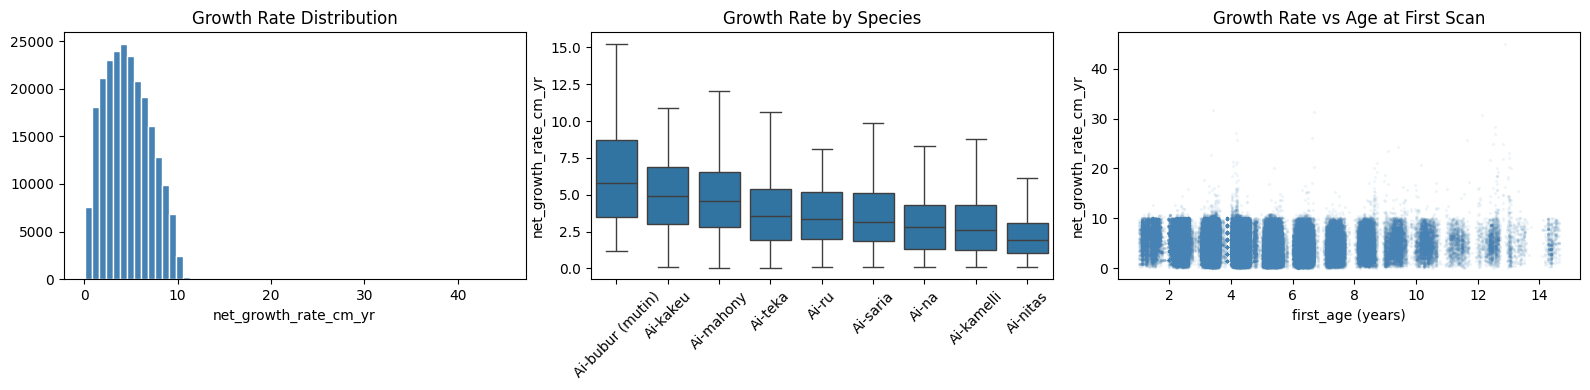


Tree count per species:
tree_species
Ai-mahony           189684
Ai-teka              19079
Ai-kakeu             14004
Ai-ru                 4558
Ai-nitas               947
Ai-saria               898
Ai-kamelli             573
Ai-na                  307
Ai-bubur (mutin)       301
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(growth_df["net_growth_rate_cm_yr"], bins=60, color="steelblue", edgecolor="white")
axes[0].set_title("Growth Rate Distribution")
axes[0].set_xlabel("net_growth_rate_cm_yr")

species_order = growth_df.groupby("tree_species")["net_growth_rate_cm_yr"].median().sort_values(ascending=False).index
sns.boxplot(data=growth_df, x="tree_species", y="net_growth_rate_cm_yr", order=species_order, ax=axes[1], showfliers=False)
axes[1].set_title("Growth Rate by Species")
axes[1].tick_params(axis="x", rotation=45)
axes[1].set_xlabel("")

axes[2].scatter(growth_df["first_age"], growth_df["net_growth_rate_cm_yr"], alpha=0.05, s=2, color="steelblue")
axes[2].set_title("Growth Rate vs Age at First Scan")
axes[2].set_xlabel("first_age (years)")
axes[2].set_ylabel("net_growth_rate_cm_yr")

plt.tight_layout()
plt.show()

print("\nTree count per species:")
print(growth_df["tree_species"].value_counts())

## 5. Feature Engineering

In [7]:
# mid_age captures the biological age during the measurement window
growth_df["mid_age"] = growth_df["first_age"] + growth_df["age_span"] / 2

# One-hot encode tree_species — each species gets its own binary column
species_dummies = pd.get_dummies(growth_df["tree_species"], prefix="species")
NUMERIC_FEATURES = ["first_age", "mid_age", "first_circ", "age_span"]
TARGET = "net_growth_rate_cm_yr"

ml_df = pd.concat(
    [growth_df[NUMERIC_FEATURES + [TARGET]], species_dummies],
    axis=1,
).dropna()

FEATURES = NUMERIC_FEATURES + list(species_dummies.columns)

print(f"ML dataset shape: {ml_df.shape}")
print(f"Features ({len(FEATURES)}): {FEATURES}")
print(f"Nulls: {ml_df.isnull().sum().sum()}")
ml_df.describe()

ML dataset shape: (230351, 6)
Nulls: 0


,species_id,first_age,mid_age,first_circ,age_span,net_growth_rate_cm_yr
count,230351.0,230351.000000,230351.000000,230351.000000,230351.000000,230351.000000
mean,7.849595,4.619310,5.256259,17.217811,1.273897,4.616179
std,2.626145,2.118339,2.189915,13.800722,0.581921,2.461560
min,1.0,1.010267,1.386721,1.000000,0.501027,0.034328
25%,9.0,3.282683,3.817933,7.500000,0.922656,2.675398
50%,9.0,4.194387,4.736482,13.000000,1.043121,4.427273
75%,9.0,5.514031,6.499658,23.000000,1.412731,6.416554
max,9.0,14.633812,15.049966,161.000000,3.488022,45.030822


## 6. Train / Test Split

In [8]:
X = ml_df[FEATURES].values
y = ml_df[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

print(f"Train: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}")

Train: 184,280  |  Test: 46,071


## 7. Model Comparison

5-fold cross-validation across four candidate models.

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

candidates = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_SEED),
}

cv_results = {}
for name, model in candidates.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=kf,
        scoring=["neg_root_mean_squared_error", "neg_mean_absolute_error", "r2"],
    )
    cv_results[name] = {
        "RMSE": -scores["test_neg_root_mean_squared_error"].mean(),
        "RMSE_std": scores["test_neg_root_mean_squared_error"].std(),
        "MAE": -scores["test_neg_mean_absolute_error"].mean(),
        "MAE_std": scores["test_neg_mean_absolute_error"].std(),
        "R2": scores["test_r2"].mean(),
    }
    print(f"{name:20s}  RMSE={cv_results[name]['RMSE']:.4f}  MAE={cv_results[name]['MAE']:.4f}  R2={cv_results[name]['R2']:.4f}")

cv_df = pd.DataFrame(cv_results).T.sort_values("RMSE")
print("\n", cv_df.round(4))

LinearRegression      RMSE=2.3034  MAE=1.8880  R2=0.1270
Ridge                 RMSE=2.3034  MAE=1.8880  R2=0.1270
RandomForest          RMSE=2.1614  MAE=1.6972  R2=0.2313
GradientBoosting      RMSE=2.2047  MAE=1.7966  R2=0.2002

                     RMSE  RMSE_std     MAE  MAE_std      R2
RandomForest      2.1614    0.0104  1.6972   0.0094  0.2313
GradientBoosting  2.2047    0.0070  1.7966   0.0054  0.2002
Ridge             2.3034    0.0061  1.8880   0.0054  0.1270
LinearRegression  2.3034    0.0061  1.8880   0.0054  0.1270


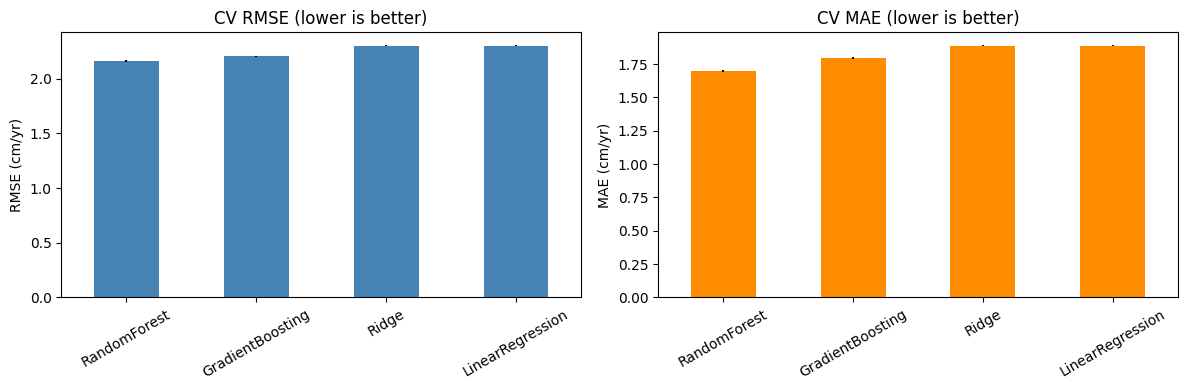

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cv_df["RMSE"].plot(kind="bar", ax=axes[0], color="steelblue", yerr=cv_df["RMSE_std"])
axes[0].set_title("CV RMSE (lower is better)")
axes[0].set_ylabel("RMSE (cm/yr)")
axes[0].tick_params(axis="x", rotation=30)

cv_df["MAE"].plot(kind="bar", ax=axes[1], color="darkorange", yerr=cv_df["MAE_std"])
axes[1].set_title("CV MAE (lower is better)")
axes[1].set_ylabel("MAE (cm/yr)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## 8. Hyperparameter Tuning

Fine-tune the best-performing model identified above.

In [11]:
best_model_name = cv_df.index[0]
print(f"Best model from CV: {best_model_name}")

tuning_grids = {
    "RandomForest": {
        "model": RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [None, 10, 20],
            "min_samples_leaf": [1, 5, 10],
        },
    },
    "GradientBoosting": {
        "model": GradientBoostingRegressor(random_state=RANDOM_SEED),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [3, 5, 7],
            "learning_rate": [0.05, 0.1, 0.2],
        },
    },
    "Ridge": {
        "model": Ridge(),
        "params": {"alpha": [0.01, 0.1, 1.0, 10.0, 100.0]},
    },
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {},
    },
}

tuning_config = tuning_grids.get(best_model_name, tuning_grids["RandomForest"])
base_model = tuning_config["model"]
param_grid = tuning_config["params"]

if param_grid:
    grid_search = GridSearchCV(
        base_model,
        param_grid,
        cv=kf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
        verbose=1,
    )
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    print(f"\nBest params: {grid_search.best_params_}")
    print(f"Best CV RMSE: {-grid_search.best_score_:.4f}")
else:
    best_model = base_model
    best_model.fit(X_train, y_train)
    print("No hyperparameters to tune — fitted directly.")

Best model from CV: RandomForest
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Best params: {'max_depth': 20, 'min_samples_leaf': 5, 'n_estimators': 200}
Best CV RMSE: 2.0532


## 9. Final Evaluation on Held-Out Test Set

In [12]:
y_pred = best_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = 1 - np.sum((y_test - y_pred) ** 2) / np.sum((y_test - y_test.mean()) ** 2)

print("=" * 50)
print(f"FINAL TEST SET EVALUATION — {best_model_name}")
print("=" * 50)
print(f"  RMSE : {rmse:.4f} cm/yr")
print(f"  MAE  : {mae:.4f} cm/yr")
print(f"  R2   : {r2:.4f}")

FINAL TEST SET EVALUATION — RandomForest
  RMSE : 2.0296 cm/yr
  MAE  : 1.6174 cm/yr
  R2   : 0.3120


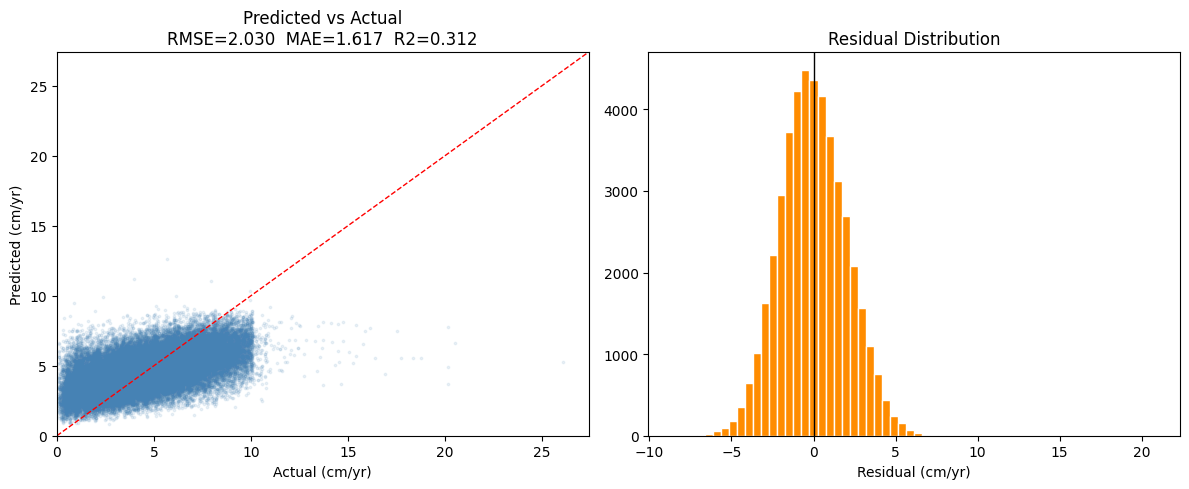

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

lim = (0, max(float(y_test.max()), float(y_pred.max())) * 1.05)
axes[0].scatter(y_test, y_pred, alpha=0.1, s=3, color="steelblue")
axes[0].plot(lim, lim, "r--", linewidth=1)
axes[0].set_xlim(lim)
axes[0].set_ylim(lim)
axes[0].set_xlabel("Actual (cm/yr)")
axes[0].set_ylabel("Predicted (cm/yr)")
axes[0].set_title(f"Predicted vs Actual\nRMSE={rmse:.3f}  MAE={mae:.3f}  R2={r2:.3f}")

residuals = y_test - y_pred
axes[1].hist(residuals, bins=60, color="darkorange", edgecolor="white")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Residual (cm/yr)")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()

## 10. Feature Importance

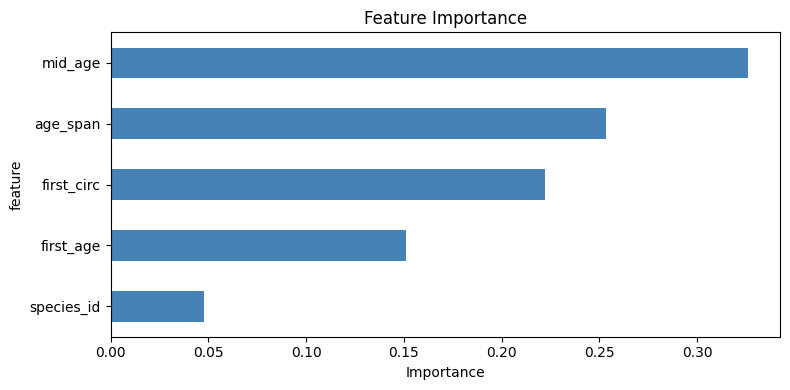

   feature  importance
   mid_age    0.326029
  age_span    0.253213
first_circ    0.221939
 first_age    0.150894
species_id    0.047926


In [14]:
if hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({"feature": FEATURES, "importance": best_model.feature_importances_}).sort_values("importance", ascending=True)

    importance_df.plot(kind="barh", x="feature", y="importance", legend=False, figsize=(8, 4), color="steelblue")
    plt.title("Feature Importance")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
    print(importance_df.sort_values("importance", ascending=False).to_string(index=False))
elif hasattr(best_model, "coef_"):
    coef_df = pd.DataFrame({"feature": FEATURES, "coefficient": best_model.coef_}).sort_values("coefficient", ascending=True)
    coef_df.plot(kind="barh", x="feature", y="coefficient", legend=False, figsize=(8, 4), color="steelblue")
    plt.title("Model Coefficients")
    plt.tight_layout()
    plt.show()
else:
    print("Feature importance not available for this model type.")

## 11. Save Model Artefacts

Saved to `src/models/growth/`.

In [15]:
import joblib

joblib.dump(best_model, MODELS_PATH / "growth_pipeline.joblib", compress=("lzma", 9))
joblib.dump(FEATURES, MODELS_PATH / "growth_feature_columns.joblib")

summary = {
    "model": best_model_name,
    "features": FEATURES,
    "target": TARGET,
    "test_rmse": round(rmse, 4),
    "test_mae": round(mae, 4),
    "test_r2": round(r2, 4),
    "train_size": int(X_train.shape[0]),
    "test_size": int(X_test.shape[0]),
}
pd.Series(summary).to_json(MODELS_PATH / "growth_model_summary.json", indent=2)

print("Saved:")
for f in sorted(MODELS_PATH.glob("*")):
    print(f"  {f.name:45s} {f.stat().st_size / 1024:.1f} KB")